# M1.Ex4: Modeling Non-linear Patterns

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [5]:
import pandas as pd
import sklearn

### Step 1. Load the data


In [6]:
bml=pd.read_csv(r"https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv")
bml.head()

,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


### Step 2.a Assign variables `X` to the features and `y` to the target

In [7]:
X = bml[["BMI"]]
y = bml["Life expectancy"]

### Step 2.b print the type of each

In [8]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

The target `Life expectancy` is **numerical** (continuous), so this is a **regression** task.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [9]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (163, 1)
y shape: (163,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [10]:
bml[["BMI", "Life expectancy"]].describe()

,BMI,Life expectancy
count,163.000000,163.000000
mean,24.792378,69.666933
std,2.427900,8.981933
min,19.866920,44.500000
25%,22.527940,63.450000
50%,25.320540,71.800000
75%,26.603960,76.500000
max,30.995630,84.600000


### Step 5. Plot the feature vs the target

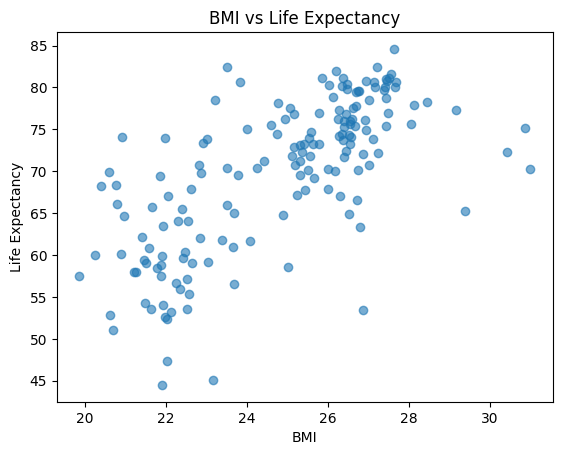

In [11]:
import matplotlib.pyplot as plt

plt.scatter(X, y, alpha=0.6)
plt.xlabel("BMI")
plt.ylabel("Life Expectancy")
plt.title("BMI vs Life Expectancy")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

The relationship is **non-linear and increasing** — as BMI increases, life expectancy tends to increase but the pattern curves rather than following a straight line.

### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

model1 = LinearRegression()
model2 = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

### Step 8. Split the dataset into train and test sets

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 130
Test size: 33


### Step 9. Train both models on the training set

In [14]:
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
print("Both models trained.")

Both models trained.


### Step 10. Evaluate and compare which of the two models score better on the `train` set

In [15]:
train_score1 = model1.score(X_train, y_train)
train_score2 = model2.score(X_train, y_train)

print(f"Linear Regression     Train R²: {train_score1:.4f}")
print(f"Polynomial Regression Train R²: {train_score2:.4f}")
better = "Polynomial" if train_score2 > train_score1 else "Linear"
print(f"Better on train set: {better} model")

Linear Regression     Train R²: 0.4940
Polynomial Regression Train R²: 0.5144
Better on train set: Polynomial model


### Step 11. Evaluate and compare which of the two models score better on the `test` set

In [16]:
test_score1 = model1.score(X_test, y_test)
test_score2 = model2.score(X_test, y_test)

print(f"Linear Regression     Test R²: {test_score1:.4f}")
print(f"Polynomial Regression Test R²: {test_score2:.4f}")
better = "Polynomial" if test_score2 > test_score1 else "Linear"
print(f"Better on test set: {better} model")

Linear Regression     Test R²: 0.3540
Polynomial Regression Test R²: 0.4031
Better on test set: Polynomial model
